# Trust Distribution Compliance Evaluation

Visualisation of trust distribution linking pipeline results.  
Evaluates document classification accuracy, field extraction accuracy,
compliance detection, and discrepancy classification
across 50 trust distribution test cases.

**Input:** `trust_evaluation_results.jsonl` (50 per-case records + 1 summary record)  
**Charts:** seaborn-based, styled for management reporting

In [1]:
# ============================================================
# Configuration & Imports
# ============================================================
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

EVALUATION_RESULTS = Path("../private_wealth_docs/output/trust_evaluation/trust_evaluation_results.jsonl")
OUTPUT_DIR = Path("../private_wealth_docs/output/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.1)

# Reference-line thresholds
PILOT_THRESHOLD = 0.80
PRODUCTION_THRESHOLD = 0.95

print(f"Results file: {EVALUATION_RESULTS}")
print(f"Output dir:   {OUTPUT_DIR}")

Results file: ../private_wealth_docs/output/trust_evaluation/trust_evaluation_results.jsonl
Output dir:   ../private_wealth_docs/output


In [2]:
# ============================================================
# Load & Parse Data
# ============================================================
raw_lines = EVALUATION_RESULTS.read_text().strip().splitlines()
all_records = [json.loads(line) for line in raw_lines]

# Separate per-case records from the summary record
summary = None
case_records: list[dict] = []
for rec in all_records:
    if "_summary" in rec:
        summary = rec["_summary"]
    else:
        case_records.append(rec)

df = pd.DataFrame(case_records)

# Explode field_accuracy dict into separate boolean columns
field_acc_df = pd.json_normalize(df["field_accuracy"])
field_acc_df.index = df.index
df = pd.concat([df.drop(columns=["field_accuracy"]), field_acc_df], axis=1)

FIELD_NAMES = list(field_acc_df.columns)

print(f"Loaded {len(case_records)} cases, summary present: {summary is not None}")
print(f"Fields: {FIELD_NAMES}")
df.head()

Loaded 50 cases, summary present: True
Fields: ['trust_abn', 'beneficiary_tfn', 'franking_credit', 'capital_gain_component', 'share_of_net_income']


,case_id,compliance_correct,predicted_status,actual_status,predicted_discrepancy,actual_discrepancy,processing_time,trust_abn,beneficiary_tfn,franking_credit,capital_gain_component,share_of_net_income
0,CASE201,False,non_compliant,compliant,trust_return_mismatch,NaN,15.295629,True,True,True,True,True
1,CASE202,True,compliant,compliant,none,NaN,14.831275,True,True,True,True,True
2,CASE203,False,non_compliant,compliant,trust_return_mismatch,NaN,14.668108,True,True,True,True,True
3,CASE204,True,compliant,compliant,none,NaN,14.515435,True,True,True,True,True
4,CASE205,True,compliant,compliant,none,NaN,14.537500,True,True,True,True,True


In [3]:
# ============================================================
# Summary Metrics Table
# ============================================================
fa = summary["field_accuracy"]
comp = summary["compliance"]
disc = summary["discrepancy_classification"]
tp = summary["throughput"]

# Classification accuracy table (optional)
cls = summary.get("classification")
if cls:
    cls_rows = [
        {"Type": doc_type, "Correct": f"{m['correct']}/{m['total']}", "Accuracy": f"{m['accuracy']:.0%}"}
        for doc_type, m in sorted(cls["per_type"].items())
    ]
    cls_rows.append(
        {
            "Type": "Overall",
            "Correct": f"{cls['correct']}/{cls['total']}",
            "Accuracy": f"{cls['accuracy']:.0%}",
        }
    )
    cls_summary = pd.DataFrame(cls_rows)
    print("=" * 50)
    print("DOCUMENT CLASSIFICATION ACCURACY")
    print("=" * 50)
    display(cls_summary.style.hide(axis="index"))
    print()

# Field accuracy table
field_summary = pd.DataFrame({"Field": list(fa.keys()), "Accuracy": list(fa.values())})
field_summary["Accuracy"] = field_summary["Accuracy"].map("{:.0%}".format)

# Compliance metrics table
compliance_summary = pd.DataFrame(
    [
        {"Metric": "Precision", "Value": f"{comp['precision']:.2%}"},
        {"Metric": "Recall", "Value": f"{comp['recall']:.2%}"},
        {"Metric": "F1 Score", "Value": f"{comp['f1']:.2%}"},
        {"Metric": "False Positive Rate", "Value": f"{comp['false_positive_rate']:.2%}"},
        {"Metric": "Discrepancy Classification Accuracy", "Value": f"{disc['accuracy']:.0%}"},
        {"Metric": "Throughput (cases/min)", "Value": f"{tp['cases_per_min']:.1f}"},
        {"Metric": "Avg seconds/case", "Value": f"{tp['avg_seconds_per_case']:.1f}"},
    ]
)

print("=" * 50)
print("FIELD EXTRACTION ACCURACY")
print("=" * 50)
display(field_summary.style.hide(axis="index"))

print()
print("=" * 50)
print("COMPLIANCE & THROUGHPUT METRICS")
print("=" * 50)
display(compliance_summary.style.hide(axis="index"))

DOCUMENT CLASSIFICATION ACCURACY


Type,Correct,Accuracy
BENEFICIARY_ITR,50/50,100%
DISTRIBUTION_STMT,50/50,100%
INCOME_SCHEDULE,50/50,100%
TRUST_RETURN,50/50,100%
Overall,200/200,100%



FIELD EXTRACTION ACCURACY


Field,Accuracy
trust_abn,94%
beneficiary_tfn,100%
franking_credit,100%
capital_gain_component,100%
share_of_net_income,98%



COMPLIANCE & THROUGHPUT METRICS


Metric,Value
Precision,75.00%
Recall,100.00%
F1 Score,85.71%
False Positive Rate,14.29%
Discrepancy Classification Accuracy,100%
Throughput (cases/min),2.1
Avg seconds/case,28.2


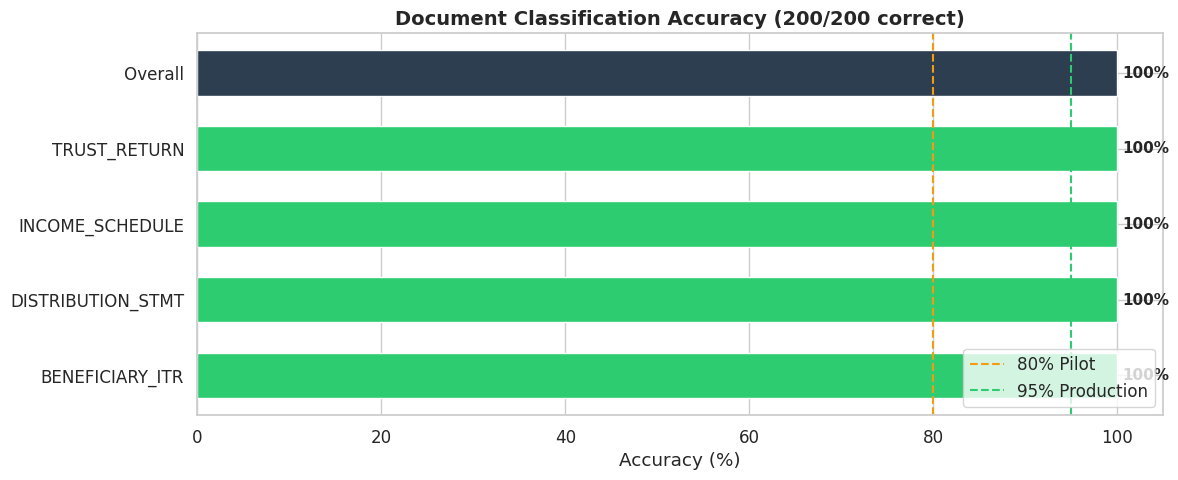

In [4]:
# ============================================================
# Document Classification Accuracy — horizontal bar chart
# ============================================================
cls = summary.get("classification")
if cls is None:
    print("No classification data in summary (--classifications not provided).")
else:
    per_type = cls["per_type"]
    types = list(per_type.keys())
    type_accs = [per_type[t]["accuracy"] * 100 for t in types]

    # Append overall
    types.append("Overall")
    type_accs.append(cls["accuracy"] * 100)

    colors = ["#2ecc71" if v >= 95 else "#f39c12" if v >= 80 else "#e74c3c" for v in type_accs]
    # Overall bar gets a distinct border
    colors[-1] = "#2c3e50" if type_accs[-1] >= 95 else "#f39c12" if type_accs[-1] >= 80 else "#e74c3c"

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(types, type_accs, color=colors, edgecolor="white", height=0.6)

    for bar, val in zip(bars, type_accs):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%",
            va="center",
            fontweight="bold",
            fontsize=11,
        )

    ax.axvline(80, color="#f39c12", linestyle="--", linewidth=1.5, label="80% Pilot")
    ax.axvline(95, color="#2ecc71", linestyle="--", linewidth=1.5, label="95% Production")

    ax.set_xlim(0, 105)
    ax.set_xlabel("Accuracy (%)")
    ax.set_title(
        f"Document Classification Accuracy ({cls['correct']}/{cls['total']} correct)",
        fontsize=14,
        fontweight="bold",
    )
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "classification_accuracy.png", dpi=150, bbox_inches="tight")
    plt.show()

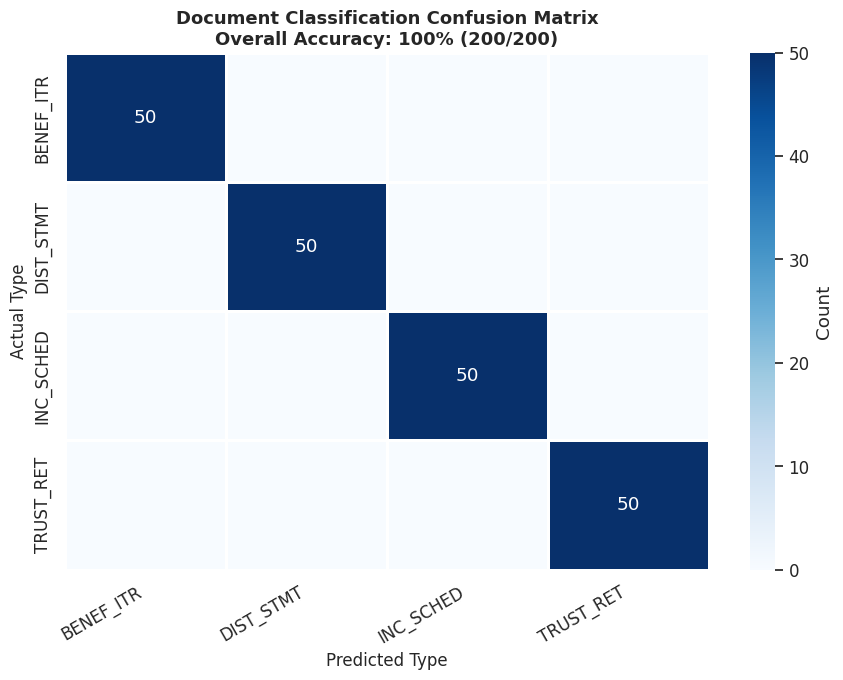

In [5]:
# ============================================================
# Document Classification Confusion Matrix
# ============================================================
cls = summary.get("classification")
if cls is None:
    print("No classification data — skipping confusion matrix.")
else:
    cm_data = cls["confusion_matrix"]
    doc_types = sorted(cm_data.keys())

    # Build matrix — rows are actual, columns are predicted
    # Include any predicted types that appear in the data but aren't in doc_types
    all_predicted = set()
    for row_data in cm_data.values():
        all_predicted.update(row_data.keys())
    col_types = sorted(all_predicted)

    matrix = np.array([[cm_data[actual].get(pred, 0) for pred in col_types] for actual in doc_types])

    # Build annotation labels with counts
    annot = np.array(
        [
            [f"{matrix[i, j]}" if matrix[i, j] > 0 else "" for j in range(len(col_types))]
            for i in range(len(doc_types))
        ]
    )

    # Shorten labels for readability
    short = {
        "TRUST_RETURN": "TRUST_RET",
        "DISTRIBUTION_STMT": "DIST_STMT",
        "INCOME_SCHEDULE": "INC_SCHED",
        "BENEFICIARY_ITR": "BENEF_ITR",
        "UNKNOWN_TRUST_DOC": "UNKNOWN",
    }
    x_labels = [short.get(t, t) for t in col_types]
    y_labels = [short.get(t, t) for t in doc_types]

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        matrix,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=x_labels,
        yticklabels=y_labels,
        linewidths=1,
        linecolor="white",
        cbar_kws={"label": "Count"},
        ax=ax,
    )
    ax.set_xlabel("Predicted Type", fontsize=12)
    ax.set_ylabel("Actual Type", fontsize=12)
    ax.set_title(
        f"Document Classification Confusion Matrix\n"
        f"Overall Accuracy: {cls['accuracy']:.0%} ({cls['correct']}/{cls['total']})",
        fontsize=13,
        fontweight="bold",
    )
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "classification_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

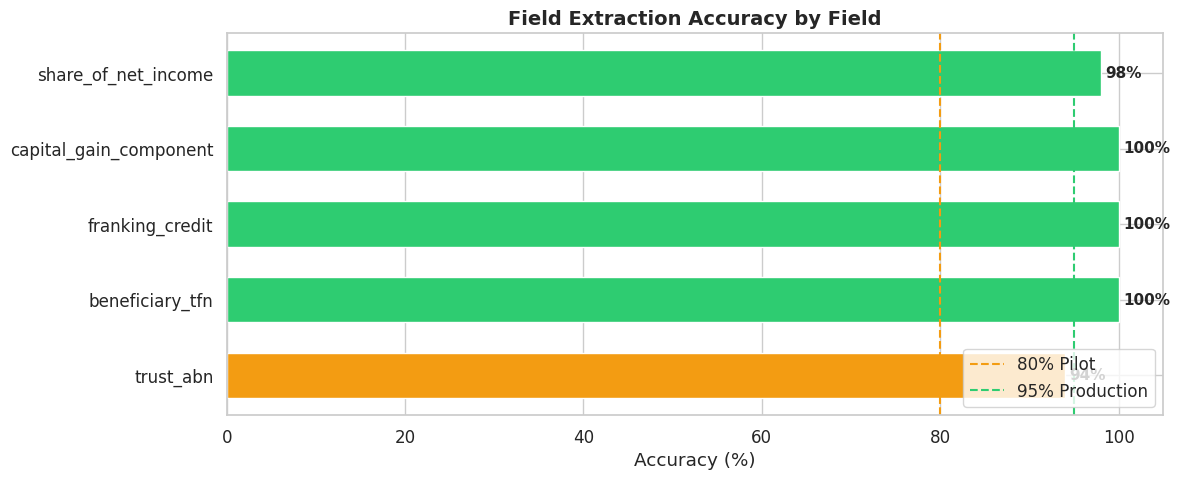

In [6]:
# ============================================================
# Field Extraction Accuracy — horizontal bar chart
# ============================================================
fa = summary["field_accuracy"]
fields = list(fa.keys())
accuracies = [fa[f] * 100 for f in fields]

# Colour by threshold
colors = ["#2ecc71" if v >= 95 else "#f39c12" if v >= 80 else "#e74c3c" for v in accuracies]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(fields, accuracies, color=colors, edgecolor="white", height=0.6)

# Annotate with percentage
for bar, val in zip(bars, accuracies):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.0f}%",
        va="center",
        fontweight="bold",
        fontsize=11,
    )

# Reference lines
ax.axvline(80, color="#f39c12", linestyle="--", linewidth=1.5, label="80% Pilot")
ax.axvline(95, color="#2ecc71", linestyle="--", linewidth=1.5, label="95% Production")

ax.set_xlim(0, 105)
ax.set_xlabel("Accuracy (%)")
ax.set_title("Field Extraction Accuracy by Field", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "field_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

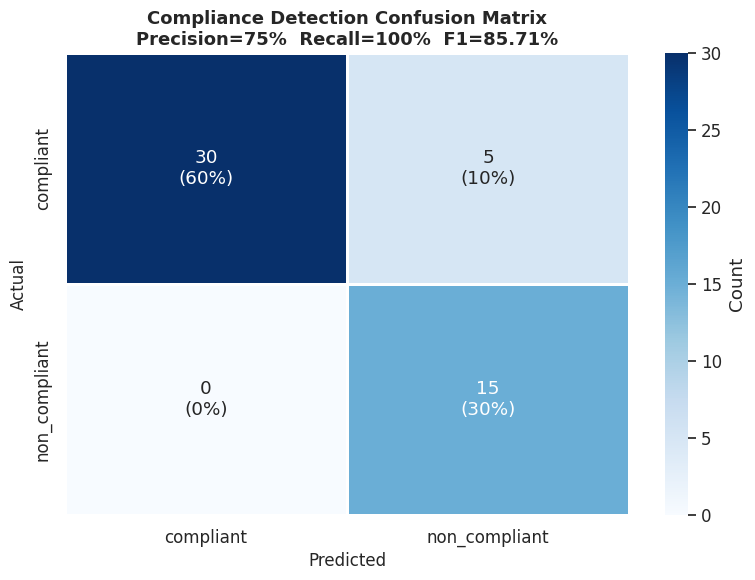

In [7]:
# ============================================================
# Compliance Detection Confusion Matrix
# ============================================================
comp = summary["compliance"]
cm = np.array(
    [
        [comp["true_negatives"], comp["false_positives"]],
        [comp["false_negatives"], comp["true_positives"]],
    ]
)

total = cm.sum()
labels = np.array(
    [
        [f"{cm[0, 0]}\n({cm[0, 0] / total:.0%})", f"{cm[0, 1]}\n({cm[0, 1] / total:.0%})"],
        [f"{cm[1, 0]}\n({cm[1, 0] / total:.0%})", f"{cm[1, 1]}\n({cm[1, 1] / total:.0%})"],
    ]
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["compliant", "non_compliant"],
    yticklabels=["compliant", "non_compliant"],
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Count"},
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title(
    "Compliance Detection Confusion Matrix\n"
    f"Precision={comp['precision']:.0%}  Recall={comp['recall']:.0%}  F1={comp['f1']:.2%}",
    fontsize=13,
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

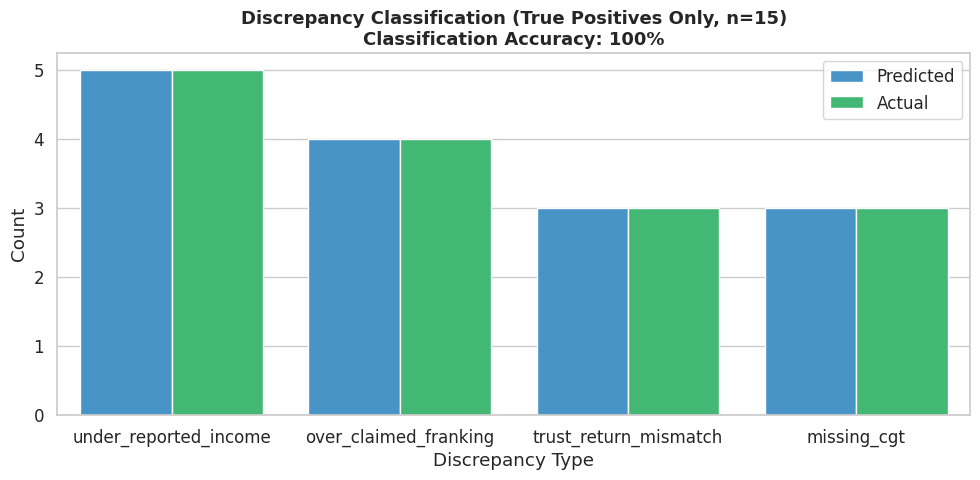

In [8]:
# ============================================================
# Discrepancy Classification Breakdown
# ============================================================
# True positives: both predicted and actual are non_compliant
tp_df = df[(df["predicted_status"] == "non_compliant") & (df["actual_status"] == "non_compliant")].copy()

if tp_df.empty:
    print("No true positive cases to plot.")
else:
    # Build long-form for grouped bar chart
    pred_counts = tp_df["predicted_discrepancy"].value_counts().rename("Predicted")
    actual_counts = tp_df["actual_discrepancy"].value_counts().rename("Actual")
    disc_df = pd.concat([pred_counts, actual_counts], axis=1).fillna(0).astype(int)
    disc_df = disc_df.reset_index().rename(columns={"index": "Discrepancy Type"})
    disc_long = disc_df.melt(id_vars="Discrepancy Type", var_name="Source", value_name="Count")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=disc_long,
        x="Discrepancy Type",
        y="Count",
        hue="Source",
        palette={"Predicted": "#3498db", "Actual": "#2ecc71"},
        edgecolor="white",
        ax=ax,
    )
    ax.set_title(
        f"Discrepancy Classification (True Positives Only, n={len(tp_df)})\n"
        f"Classification Accuracy: {summary['discrepancy_classification']['accuracy']:.0%}",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_ylabel("Count")
    ax.legend(title="")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "discrepancy_classification.png", dpi=150, bbox_inches="tight")
    plt.show()

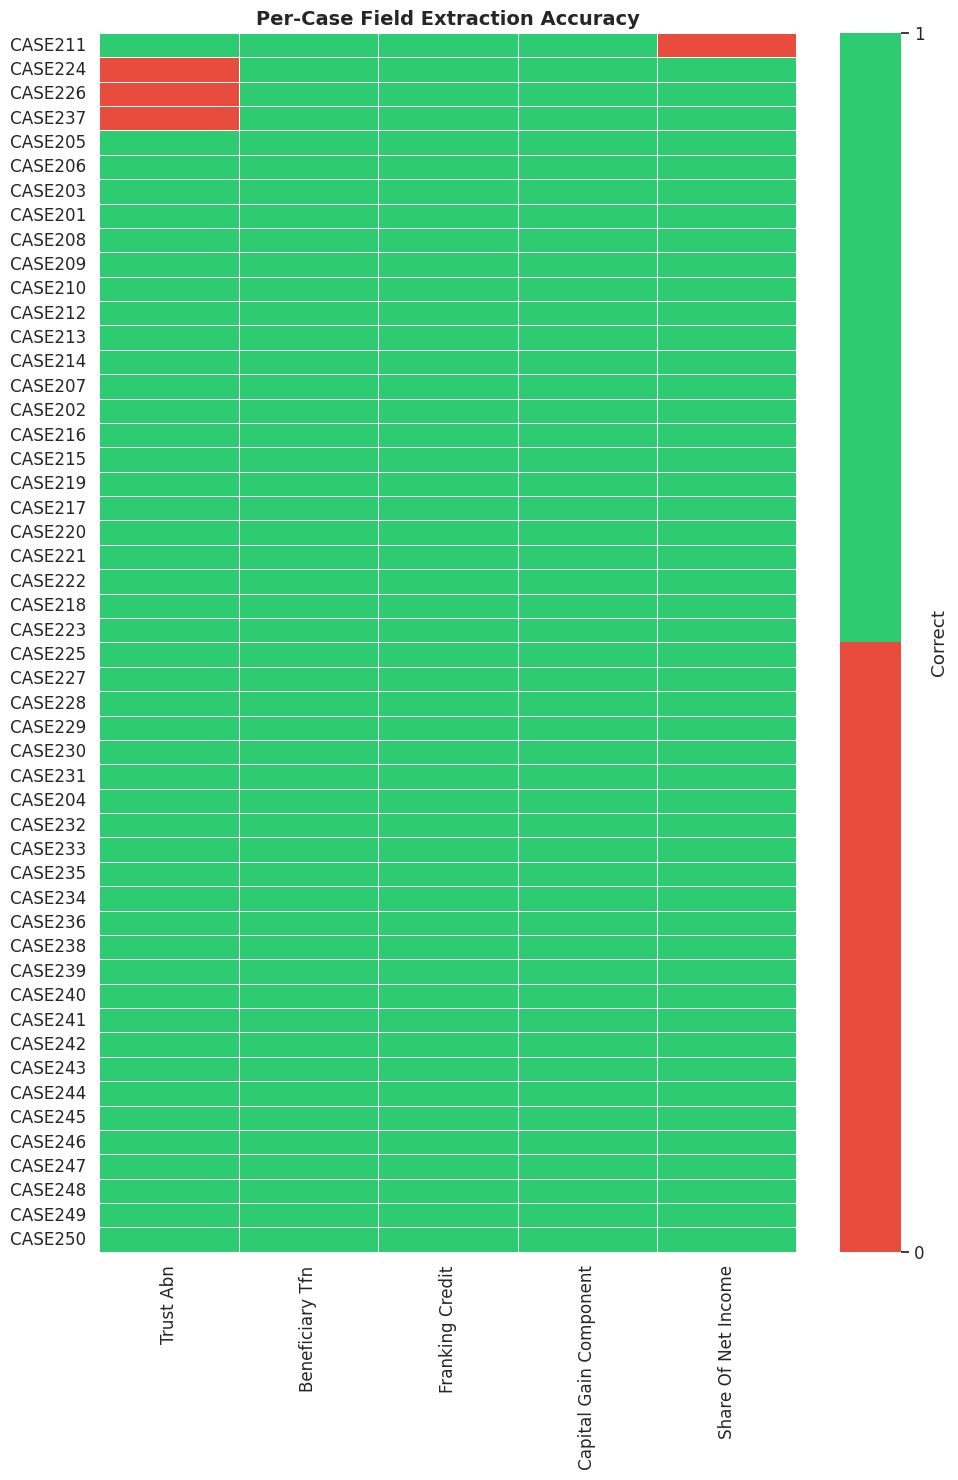

In [9]:
# ============================================================
# Per-Case Field Accuracy Heatmap
# ============================================================
heat_data = df.set_index("case_id")[FIELD_NAMES].astype(int)

# Sort so cases with failures appear at the top
heat_data = heat_data.loc[heat_data.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, max(6, len(heat_data) * 0.3)))
sns.heatmap(
    heat_data,
    cmap=["#e74c3c", "#2ecc71"],
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correct", "ticks": [0, 1]},
    xticklabels=[f.replace("_", " ").title() for f in FIELD_NAMES],
    yticklabels=True,
    ax=ax,
)
ax.set_title("Per-Case Field Extraction Accuracy", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "per_case_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ============================================================
# False Positive Analysis
# ============================================================
fp_df = df[(df["predicted_status"] == "non_compliant") & (df["actual_status"] == "compliant")][
    ["case_id", "predicted_discrepancy", "actual_discrepancy"]
].copy()

fp_df = fp_df.rename(
    columns={
        "case_id": "Case ID",
        "predicted_discrepancy": "Predicted Discrepancy",
        "actual_discrepancy": "Actual Discrepancy",
    }
)
fp_df["Actual Discrepancy"] = fp_df["Actual Discrepancy"].fillna("none (compliant)")

print("=" * 60)
print(f"FALSE POSITIVE CASES ({len(fp_df)} cases)")
print("=" * 60)
print("These cases were incorrectly flagged as non-compliant.")
print()
display(fp_df.style.hide(axis="index"))

FALSE POSITIVE CASES (5 cases)
These cases were incorrectly flagged as non-compliant.



Case ID,Predicted Discrepancy,Actual Discrepancy
CASE201,trust_return_mismatch,none (compliant)
CASE203,trust_return_mismatch,none (compliant)
CASE211,under_reported_income,none (compliant)
CASE221,trust_return_mismatch,none (compliant)
CASE234,trust_return_mismatch,none (compliant)


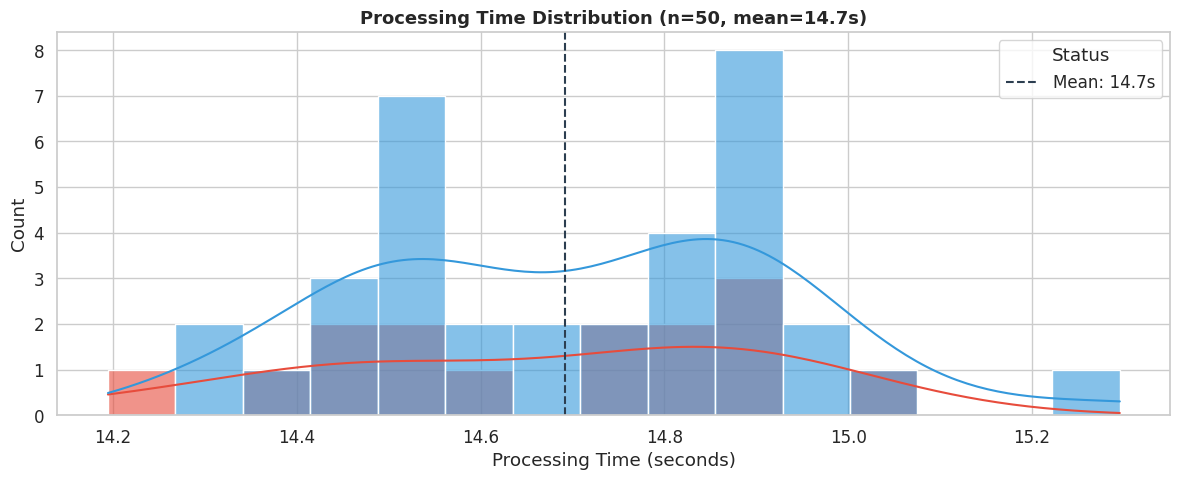

In [11]:
# ============================================================
# Processing Time Distribution
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=df,
    x="processing_time",
    hue="actual_status",
    palette={"compliant": "#3498db", "non_compliant": "#e74c3c"},
    kde=True,
    bins=15,
    alpha=0.6,
    edgecolor="white",
    ax=ax,
)

mean_time = df["processing_time"].mean()
ax.axvline(
    mean_time,
    color="#2c3e50",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {mean_time:.1f}s",
)

ax.set_xlabel("Processing Time (seconds)")
ax.set_ylabel("Count")
ax.set_title(
    f"Processing Time Distribution (n={len(df)}, mean={mean_time:.1f}s)",
    fontsize=13,
    fontweight="bold",
)
ax.legend(title="Status")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "processing_time.png", dpi=150, bbox_inches="tight")
plt.show()